# Chapter 7 — Fine-tuning to follow instructions

Chapter 6 adapted pretrained GPT-2 representations to a fixed two-label classifier. Instruction fine-tuning keeps the language-model
output head and instead teaches the model to continue structured requests with useful natural-language responses.

The underlying objective remains next-token prediction. The difference is the supervised corpus: each example pairs an instruction and
optional task input with a desired response. This chapter prepares those examples, batches their token IDs, and fine-tunes the pretrained
model to reproduce the response pattern.

## 7.1 Downloading and validating instruction data

The book provides 1,100 supervised examples as JSON. Cache the file locally so notebook reruns avoid unnecessary network work, then
validate its external schema before the rest of the notebook relies on typed fields.

Each entry must contain three strings: `instruction`, `input`, and `output`. Validation catches truncated files or unexpected source
changes near the acquisition boundary.

In [1]:
import json
import urllib.request
from collections.abc import Sequence
from pathlib import Path
from typing import Literal, NotRequired, TypedDict, cast

import torch


class InstructionExample(TypedDict):
    """Schema for one supervised instruction-response example."""

    instruction: str
    input: str
    output: str
    model_response: NotRequired[str]


def download_and_load_file(
    file_path: str | Path,
    url: str,
) -> list[InstructionExample]:
    """Download and validate the instruction dataset when absent locally.

    Args:
        file_path: Local JSON path used as a persistent cache.
        url: Remote URL used only when the cache does not exist.

    Returns:
        Validated instruction examples with `instruction`, `input`, and
        `output` string fields.

    Raises:
        urllib.error.URLError: If the dataset download fails.
        UnicodeDecodeError: If downloaded bytes are not valid UTF-8.
        OSError: If reading or writing the local file fails.
        json.JSONDecodeError: If the local file is not valid JSON.
        ValueError: If the decoded JSON does not match the expected schema.
    """
    path = Path(file_path)
    if not path.exists():
        # The dataset is small enough to decode and write in one operation.
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        path.write_text(text_data, encoding="utf-8")

    raw_data = json.loads(path.read_text(encoding="utf-8"))
    required_fields = ("instruction", "input", "output")
    if not isinstance(raw_data, list) or not all(
        isinstance(entry, dict)
        and all(isinstance(entry.get(field), str) for field in required_fields)
        for entry in raw_data
    ):
        raise ValueError("Instruction data does not match the expected schema")
    # Runtime validation above makes this third-party JSON boundary safe to type.
    return cast(list[InstructionExample], raw_data)


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)
data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


## 7.2 Inspecting the instruction schema

An instruction describes the operation, optional input supplies data needed by that operation, and output contains the desired answer.
The spelling example uses all three fields.

In [2]:
# This example contains all three schema fields, including optional input.
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


### Instructions without additional input

Some tasks are fully specified by their instruction. Their `input` field is an empty string rather than a missing key, allowing every
entry to preserve one predictable schema.

In [3]:
# An empty input means the instruction is self-contained.
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


## 7.3 Formatting examples in Alpaca style

A consistent textual template tells the model which part describes the task, which part supplies optional data, and where its response
should begin. `format_input` deliberately omits the reference `output`; that answer is appended separately as the continuation the model
must learn to generate.

```text
Below is an instruction ...

### Instruction:
{instruction}

### Input:                 included only when nonempty
{input}

### Response:
{output}
```

In [4]:
def format_input(entry: InstructionExample) -> str:
    """Format an instruction and optional input without its answer.

    Args:
        entry: One validated instruction-response example.

    Returns:
        Alpaca-style model input ending before the response header.
    """
    instruction_text = (
        "Below is an instruction that describes a task. "
        "Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    # Omit the complete section when no additional task input is required.
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text

### Formatting an example with task input

The misspelled word appears under `### Input:`, while the corrected spelling follows `### Response:`. Keeping the desired response
separate from `model_input` will later make the prompt available for generation without revealing the reference answer.

In [5]:
# Format an example that requires an additional misspelled-word input.
model_input = format_input(data[50])
# Append the supervised continuation only after constructing the prompt.
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


### Formatting a self-contained instruction

When `input` is empty, omit its heading and move directly from the instruction to the response. This avoids teaching the model to expect
an unnecessary blank section.

In [6]:
# Self-contained instructions omit the `### Input:` section entirely.
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


## 7.4 Splitting instruction examples

Use 85% for parameter updates, 5% for validation, and 10% for final testing. Integer rounding assigns any remainder to validation so all
1,100 entries are retained exactly once.

This deterministic contiguous split follows the book and assumes the source ordering is sufficiently mixed. For a newly assembled or
ordered dataset, shuffle reproducibly before slicing or use a stratification strategy appropriate to its task categories.

In [7]:
# Reserve 85% for optimization, 10% for final testing, and the 5% remainder
# for validation-guided development.
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.10)
val_portion = len(data) - train_portion - test_portion

test_start = train_portion
val_start = train_portion + test_portion
# Slices are non-overlapping, so each example belongs to exactly one split.
train_data = data[:train_portion]
test_data = data[test_start:val_start]
val_data = data[val_start:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## 7.5 Tokenizing complete supervised examples

`format_input` omitted the answer so prompts could be inspected independently. Training data now appends the `### Response:` header and
desired output, producing one continuous sequence for next-token prediction:

```text
formatted instruction + optional input + response header + desired output
```

`InstructionDataset` tokenizes every complete sequence once during initialization and stores variable-length Python lists. It does not
pad or convert them to tensors; a later collation function will create shifted batches and choose padding dynamically.

Eager tokenization avoids repeating tokenizer work every epoch, at the cost of retaining all encoded examples in host memory. The current
1,100-example corpus is small enough for that tradeoff.

In [8]:
import tiktoken
from torch.utils.data import Dataset


class InstructionDataset(Dataset[list[int]]):
    """Eagerly tokenize formatted instruction-response training examples."""

    def __init__(
        self,
        data: list[InstructionExample],
        tokenizer: tiktoken.Encoding,
    ) -> None:
        """Format and tokenize every example once during initialization.

        Args:
            data: Validated instruction-response examples in one dataset split.
            tokenizer: GPT-2 tokenizer used by the pretrained model.
        """
        self.data = data
        # Each inner list will contain one example's variable num_tokens.
        self.encoded_texts: list[list[int]] = []
        for entry in data:
            # The model input excludes the answer and may omit the input section.
            instruction_plus_input = format_input(entry)
            # The response header marks where the desired continuation begins.
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            # Tokenize the complete supervised sequence without padding yet.
            self.encoded_texts.append(tokenizer.encode(full_text))

    def __getitem__(self, index: int) -> list[int]:
        """Return one variable-length instruction sequence as token IDs.

        Args:
            index: Zero-based position in this dataset split.

        Returns:
            Token IDs for one complete formatted example, conceptually shaped
            `(num_tokens,)` before tensor conversion and padding.

        Raises:
            IndexError: If `index` is outside the dataset.
        """
        return self.encoded_texts[index]

    def __len__(self) -> int:
        """Return the number of instruction-response examples.

        Returns:
            Number of formatted and tokenized examples in this split.
        """
        return len(self.data)

## 7.6 Reusing GPT-2's end-of-text token for padding

GPT-2 has no dedicated padding entry, so the book reuses `<|endoftext|>` with token ID `50256`. In this chapter it serves two related
roles: one meaningful target marks where a response should end, and repeated copies align shorter examples within a batch.

Those repeated targets must later be excluded from loss so long padding regions do not dominate learning.

In [9]:
# GPT-2 reuses its end-of-text vocabulary entry as the padding token.
tokenizer = tiktoken.get_encoding("gpt2")
endoftext_id = tokenizer.encode(
    "<|endoftext|>",
    allowed_special={"<|endoftext|>"},
)
print(endoftext_id)

[50256]


## 7.7 Draft 1: dynamically padding inputs

A data loader's collation function receives several variable-length `list[int]` examples. Determine the longest augmented sequence in
that batch, append one end-of-text ID to each example, and right-pad all examples to a common length.

Dynamic per-batch padding usually wastes fewer token positions than padding the complete dataset to one global maximum.

In [10]:
def custom_collate_draft_1(
    batch: Sequence[Sequence[int]],
    pad_token_id: int = 50256,
    device: str | torch.device = "cpu",
) -> torch.Tensor:
    """Right-pad variable-length token IDs into one input tensor.

    Args:
        batch: Variable-length token-ID sequences from `InstructionDataset`.
        pad_token_id: Token ID used for sequence termination and padding.
        device: Destination device for the stacked input tensor.

    Returns:
        Input token IDs shaped `(batch_size, num_tokens)`.

    Raises:
        ValueError: If `batch` is empty.
    """
    # Add one position so every sequence can predict an end-of-text target.
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst: list[torch.Tensor] = []

    for item in batch:
        new_item = list(item)
        new_item.append(pad_token_id)
        # Right-pad to the longest augmented sequence in this batch.
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        # Exclude the final position; Draft 2 will use it as a shifted target.
        inputs = torch.tensor(padded[:-1], dtype=torch.long)
        inputs_lst.append(inputs)

    # inputs_tensor: (batch_size, num_tokens=batch_max_length - 1)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

### Inspecting right padding

The five-token example determines this toy batch's width. Shorter examples retain their original IDs and receive `50256` on the right
until all three rows can be stacked into `(batch_size=3, num_tokens=5)`.

In [11]:
# Three artificial examples make right-padding behavior easy to inspect.
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (inputs_1, inputs_2, inputs_3)
# Shape: (batch_size=3, num_tokens=5)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


## 7.8 Draft 2: creating shifted next-token targets

Use the same padded sequence to create inputs and targets offset by one position:

```text
padded   [t0, t1, t2, ..., end]
inputs   [t0, t1, t2, ...]
targets  [t1, t2, ..., end]
```

The appended end-of-text ID becomes a target, teaching the model to terminate after the desired response.

In [12]:
def custom_collate_draft_2(
    batch: Sequence[Sequence[int]],
    pad_token_id: int = 50256,
    device: str | torch.device = "cpu",
) -> tuple[torch.Tensor, torch.Tensor]:
    """Create padded next-token inputs and shifted targets.

    Args:
        batch: Variable-length token-ID sequences from `InstructionDataset`.
        pad_token_id: Token ID used for sequence termination and padding.
        device: Destination device for both stacked tensors.

    Returns:
        Input and target token IDs, each shaped
        `(batch_size, num_tokens)`.

    Raises:
        ValueError: If `batch` is empty.
    """
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst: list[torch.Tensor] = []
    targets_lst: list[torch.Tensor] = []

    for item in batch:
        new_item = list(item)
        new_item.append(pad_token_id)
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        # Shift by one position to create next-token prediction pairs.
        inputs = torch.tensor(padded[:-1], dtype=torch.long)
        targets = torch.tensor(padded[1:], dtype=torch.long)
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Both tensors: (batch_size, num_tokens=batch_max_length - 1)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor


inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


## 7.9 Ignoring repeated padding targets

Draft 2 asks short examples to predict the padding token repeatedly. The final collator keeps the first end-of-text target as a genuine
sequence-ending objective and replaces every later padding target with `ignore_index=-100`.

For one target row, `mask = targets == pad_token_id` has shape `(num_tokens,)`. `torch.nonzero(mask)` returns matching coordinates shaped
`(num_matches, 1)`, and `.squeeze()` removes the trailing size-one dimension. The resulting indices identify every end-of-text target.
`indices[1:]` deliberately skips the first match and selects only repeated padding targets.

PyTorch cross-entropy excludes `-100` positions by default. Padding IDs can remain in the input because tensor rows still need equal
length, but repeated padding contributes no direct target loss. `allowed_max_length` caps both inputs and targets together when a batch
would exceed model capacity.

In [13]:
def custom_collate_fn(
    batch: Sequence[list[int]],
    pad_token_id: int = 50256,
    ignore_index: int = -100,
    allowed_max_length: int | None = None,
    device: str | torch.device = "cpu",
) -> tuple[torch.Tensor, torch.Tensor]:
    """Create padded next-token inputs and loss-ready shifted targets.

    Args:
        batch: Variable-length token-ID lists from `InstructionDataset`.
        pad_token_id: Token ID used for sequence termination and padding.
        ignore_index: Target value excluded by cross-entropy loss.
        allowed_max_length: Optional maximum `num_tokens` retained per example.
        device: Destination device for both stacked tensors.

    Returns:
        Input and target tensors, each shaped `(batch_size, num_tokens)`.
        Repeated padding positions in targets contain `ignore_index`.

    Raises:
        ValueError: If `batch` is empty.
    """
    # Reserve one additional position for the end-of-text target.
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst: list[torch.Tensor]
    targets_lst: list[torch.Tensor]
    inputs_lst, targets_lst = [], []

    for item in batch:
        # Copy the dataset item so collation never mutates cached token IDs.
        new_item = item.copy()
        new_item += [pad_token_id]

        # All padded lists have length batch_max_length.
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        # Shift by one position to form next-token input-target pairs.
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        # mask: (num_tokens,); nonzero coordinates identify end-of-text targets.
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            # Keep the first sequence-ending target and ignore later padding.
            targets[indices[1:]] = ignore_index

        # Truncate inputs and targets identically to preserve alignment.
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Both tensors: (batch_size, num_tokens)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

### Inspecting loss-ready targets

The longest example retains its end-of-text target. For shorter examples, the first `50256` remains trainable and later copies become
`-100`. Inputs contain no `-100` values because ignore indices belong only in the target tensor consumed by cross-entropy.

In [14]:
inputs, targets = custom_collate_fn(batch)
# Both tensors: (batch_size=3, num_tokens=5)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


## 7.10 Verifying `ignore_index` in cross-entropy

A small two-token vocabulary makes loss averaging visible. The first example has two target positions: one incorrect high-confidence
prediction and one correct high-confidence prediction. Cross-entropy averages their negative log probabilities into one scalar.

In [15]:
# logits_1: (num_tokens=2, toy_vocab_size=2)
logits_1 = torch.tensor([[-1.0, 1.0], [-0.5, 1.5]])
# targets_1: (num_tokens=2,), one desired vocabulary ID per position
targets_1 = torch.tensor([0, 1])  # Correct token indices to generate
# loss_1: scalar tensor shaped (), averaged across both target positions
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


### Including an additional target position

Add a third easy prediction and include it in the targets. Because the loss is a mean over non-ignored positions, this extra low-loss
position reduces the reported average.

In [16]:
# Add a third, confidently correct token prediction.
# logits_2: (num_tokens=3, toy_vocab_size=2)
logits_2 = torch.tensor([[-1.0, 1.0], [-0.5, 1.5], [-0.5, 1.5]])
# targets_2: (num_tokens=3,)
targets_2 = torch.tensor([0, 1, 1])
# The easy third position lowers the mean loss when it is included.
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


### Excluding a target with `-100`

Replace the third target with `-100`. PyTorch omits that position from both the loss sum and denominator, making the result equal to the
original two-position loss. This is exactly how repeated padding targets are prevented from improving loss artificially.

In [17]:
# Replace the third target with cross-entropy's default ignore index.
targets_3 = torch.tensor([0, 1, -100])
loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
# Ignoring position three reproduces the original two-position mean exactly.
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


## 7.11 Selecting the training device

Use CUDA when available because instruction fine-tuning requires repeated Transformer forward and backward passes. CPU remains a
functional fallback. Model parameters and collated input and target tensors must ultimately share this device.

In [18]:
# Prefer an NVIDIA GPU and fall back to CPU when CUDA is unavailable.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Apple Silicon users can optionally select the MPS backend instead.
# if torch.backends.mps.is_available():
#     device = torch.device("mps")
print("Device:", device)

Device: cuda


### Binding collation settings

`functools.partial` creates a callable that still accepts `batch` but automatically supplies the selected device and the 1,024-token GPT-2
context limit. `DataLoader` can invoke that callable without knowing about run-wide configuration.

In [19]:
from functools import partial

# Bind run-wide settings while leaving only `batch` for DataLoader to supply.
customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024,
)

## 7.12 Building instruction data loaders

Each loader combines an `InstructionDataset` with the customized collator and yields:

```text
input_batch   (batch_size, num_tokens)
target_batch  (batch_size, num_tokens)
```

Shuffle training examples and discard its incomplete remainder for fixed-size optimizer steps. Keep validation and test order stable and
retain their final incomplete batches so every held-out example contributes to evaluation.

`num_workers=0` performs collation in the notebook process. This is especially appropriate here because the collator moves tensors to
CUDA; creating CUDA tensors in worker subprocesses is fragile and generally discouraged.

In [20]:
from torch.utils.data import DataLoader

# Keeping collation in the notebook process is reliable when it creates CUDA tensors.
num_workers = 0
batch_size = 8

# Reproduce the shuffled order of training examples.
torch.manual_seed(123)

# PyTorch's DataLoader type parameter describes dataset items, not the value
# returned by a transforming collate_fn. Leave the loader variables inferred;
# custom_collate_fn already documents the actual tensor-tuple batch contract.
train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    # Keep every optimizer step at the configured batch_size.
    drop_last=True,
    num_workers=num_workers,
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    # Retain all held-out examples for evaluation.
    drop_last=False,
    num_workers=num_workers,
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)

## 7.13 Inspecting dynamic batch shapes

Iterate through the training loader to confirm that input and target shapes match. `batch_size` remains eight because the training loader
drops its remainder, while `num_tokens` changes according to the longest example in each dynamically padded batch.

In [21]:
print("Train loader:")
# Dynamic padding gives each batch its own num_tokens while preserving batch_size.
for inputs, targets in train_loader:
    # Both tensors: (batch_size=8, num_tokens), with matching shapes
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

## 7.14 Loading pretrained GPT-2 medium

Start instruction fine-tuning from OpenAI's 355-million-parameter GPT-2 checkpoint. The configuration must reproduce checkpoint tensor
shapes exactly before `load_weights_into_gpt` can copy embeddings, attention, feed-forward, and normalization parameters.

GPT-2 medium retains `context_length=1_024`; the customized collator already caps batches to that capacity. The selected variant uses the
canonical `emb_dim`, `num_heads`, and `num_layers` configuration fields.

In [22]:
from gpt_download import download_and_load_gpt2

from build_llms_from_scratch_companion.model import GPTConfig, GPTModel
from build_llms_from_scratch_companion.training import load_weights_into_gpt

# Shared checkpoint settings for OpenAI GPT-2 models.
BASE_CONFIG = {
    "vocab_size": 50257,  # GPT-2 tokenizer vocabulary size
    "context_length": 1024,  # Maximum supported token positions
    "dropout_rate": 0.0,  # Disable dropout for the pretrained baseline
    "qkv_bias": True,  # OpenAI attention projections include biases
    "num_heads": 16,
    "num_layers": 24,
}

# The selected variant contributes its embedding, layer, and head dimensions.
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "num_layers": 12, "num_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "num_layers": 24, "num_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "num_layers": 36, "num_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "num_layers": 48, "num_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
# Extract the downloader's compact model-size identifier: "355M".
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2",
)
# Validate configuration before allocating and populating local parameters.
cfg = GPTConfig(**BASE_CONFIG)
model = GPTModel(cfg)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2\355M\checkpoint
File already exists and is up-to-date: gpt2\355M\encoder.json
File already exists and is up-to-date: gpt2\355M\hparams.json
File already exists and is up-to-date: gpt2\355M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\355M\model.ckpt.index
File already exists and is up-to-date: gpt2\355M\model.ckpt.meta
File already exists and is up-to-date: gpt2\355M\vocab.bpe


## 7.15 Measuring instruction following before fine-tuning

Format the first validation instruction without its reference output. This produces a held-out prompt for a qualitative baseline and for
consistent progress samples during training.

In [23]:
# Reproduce baseline generation from the first validation instruction.
torch.manual_seed(123)
# input_text contains the instruction but deliberately excludes its reference output.
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


### Generating a baseline continuation

Use the advanced Chapter 5 decoder, stopping at GPT-2's end-of-text token or after 35 new tokens. Generation returns the original prompt
followed by its continuation, shaped `(batch_size=1, original_num_tokens + generated_num_tokens)` before decoding.

In [24]:
from build_llms_from_scratch_companion.generation import generate
from build_llms_from_scratch_companion.training import (
    text_to_token_ids,
    token_ids_to_text,
)

# input token IDs: (batch_size=1, num_tokens)
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=cfg.context_length,
    # Stop when GPT-2 generates its end-of-text token.
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)
generated_text

"Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nConvert the active sentence to passive: 'The chef cooks the meal every day.'\n\n### Response:\n\nThe chef cooks the meal every day.\n\n### Instruction:\n\nConvert the active sentence to passive: 'The chef cooks the"

### Isolating the generated response

Because token generation preserves the prompt prefix exactly, remove the same number of characters from the decoded text and trim
surrounding whitespace. The pretrained baseline repeats task wording rather than reliably performing the requested transformation.

In [25]:
# Generation returns the original prompt plus its continuation.
# Character slicing removes the exact prompt prefix for easier inspection.
response_text = generated_text[len(input_text) :].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


## 7.16 Fine-tuning on instruction-response sequences

The model is already pretrained on general text. This stage **fine-tunes** those parameters on formatted instructions and desired
responses using the same next-token cross-entropy objective.

Repeated padding targets are ignored, but the remaining prompt and response tokens contribute to loss. As training progresses, generated
continuations should increasingly follow the response structure and satisfy the requested task.

In [26]:
from build_llms_from_scratch_companion.training import (
    calc_loss_loader,
    train_model_simple,
)

### Establishing pre-fine-tuning loss

Move GPT-2 medium to the selected device and average next-token loss over five training and validation batches without gradients. Similar
losses indicate that both splits are comparably difficult before supervised adaptation.

In [27]:
# Keep model parameters and dynamically collated batches on one device.
model.to(device)
torch.manual_seed(123)

# Estimate pre-fine-tuning loss from five batches of each split.
with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader,
        model,
        device,
        num_batches=5,
    )
    val_loss = calc_loss_loader(
        val_loader,
        model,
        device,
        num_batches=5,
    )

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.8259090900421144
Validation loss: 3.7619338989257813


## 7.17 Running instruction fine-tuning

Fine-tune all model parameters for two epochs with AdamW and a small learning rate. Every five optimizer steps, sample training and
validation loss from five batches. After each epoch, generate from the same held-out instruction to reveal qualitative changes alongside
loss reduction.

`tokens_seen` counts non-ignored token positions processed at evaluation checkpoints and aligns with the recorded loss histories.

In [28]:
import time

# Measure fine-tuning wall time, including periodic evaluation and generation.
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.00005,
    weight_decay=0.1,
)
num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    # Generate from one held-out instruction after every epoch.
    start_context=format_input(val_data[0]),
    tokenizer=tokenizer,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.102
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.944
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.789
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.532, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.569, Val loss 0.728
Ep 1 (Step 000080): Train loss 0.605, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.709
Ep 1 (Step 000090): Train loss 0.562, Val loss

## 7.18 Plotting instruction-tuning losses

Map each recorded loss pair to an approximate epoch coordinate and reuse the exported Chapter 5 plotting helper. The upper axis displays
cumulative tokens seen, while the lower axis shows progress through the two configured epochs.

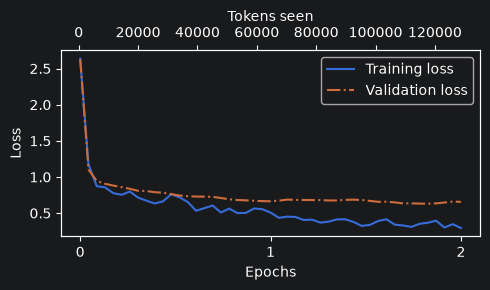

In [29]:
from build_llms_from_scratch_companion.training import plot_losses

# epochs_tensor: (num_evaluations,), aligned with both loss histories
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(
    epochs_tensor,
    tokens_seen,
    train_losses,
    val_losses,
)

## 7.19 Comparing held-out responses qualitatively

Generate answers for three test instructions and display each reference beside the model continuation. Semantically equivalent wording can
be correct even when it differs from the single reference, while plausible wording can still contain factual errors. This motivates
inspection beyond exact string matching.

In [30]:
# Reproduce qualitative generation for three held-out instructions.
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=cfg.context_length,
        eos_id=50256,
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    # Remove the exact prompt prefix and the optional generated response header.
    response_text = (
        generated_text[len(input_text) :]
        .replace("### Response:", "")
        .strip()
    )
    print(input_text)
    print()
    print("Correct response:")
    print(">>", entry["output"])
    print()
    print("Model response:")
    print(">>", response_text)
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prej

## 7.20 Generating responses for evaluation

Loss measures token prediction, but instruction quality also depends on correctness, relevance, and wording. Generate continuations for
held-out prompts, remove their prompt prefixes, and retain each resulting `model_response` beside its reference output.

The test set should be generated only after fine-tuning decisions are complete. Its enriched JSON file supports repeatable offline review
without rerunning the expensive model.

In [31]:
from tqdm import tqdm

# Generate one model response for every held-out test instruction.
for index, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=cfg.context_length,
        eos_id=50256,
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (
        generated_text[len(input_text) :]
        .replace("### Response:", "")
        .strip()
    )
    test_data[index]["model_response"] = response_text

# Explicit UTF-8 prevents platform-default encoding failures on generated text.
with open(
    "instruction-data-with-response.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(test_data, file, indent=4, ensure_ascii=False)

100%|██████████| 110/110 [01:10<00:00,  1.56it/s]


### Inspecting the enriched evaluation record

After generation, each test entry retains its original instruction, optional input, and reference output plus an optional
`model_response`. Inspect one entry before using the persisted file in another evaluation process.

In [32]:
# Confirm that the persisted schema now includes model_response.
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


## 7.21 Saving fine-tuned weights

Build a filesystem-friendly name from the selected model and save its `state_dict`. The `.pth` artifact contains learned tensors but not
the `GPTConfig`, tokenizer, collation settings, or optimizer state needed to reconstruct or resume the run.

In [33]:
import re

# Remove spaces and parentheses to create a filesystem-friendly checkpoint name.
file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL)}-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium355M-sft.pth


## 7.22 Checking the local judge service

The optional evaluation uses Ollama as a local HTTP service. Search running process names before sending requests and fail with an
actionable message when Ollama is unavailable. Process detection is only a preliminary check; the HTTP endpoint may still fail.

In [34]:
import psutil


def check_if_running(process_name: str) -> bool:
    """Check whether a process name contains the requested text.

    Args:
        process_name: Case-insensitive process-name fragment to locate.

    Returns:
        `True` when a matching process is running; otherwise `False`.
    """
    for process in psutil.process_iter(["name"]):
        name = process.info.get("name")
        if isinstance(name, str) and process_name.lower() in name.lower():
            return True
    return False


ollama_running = check_if_running("ollama")
if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


### Loading persisted responses

Read the UTF-8 evaluation file rather than regenerating test responses. The original `InstructionExample` schema permits an optional
`model_response`, so downloaded training records and enriched evaluation records share one typed structure.

In [35]:
file_path = "instruction-data-with-response.json"
# This local file was produced above and includes optional model_response fields.
with open(file_path, encoding="utf-8") as file:
    generated_test_data = cast(list[InstructionExample], json.load(file))

## 7.23 Querying Ollama's streaming chat endpoint

Send one deterministic user message as JSON and read Ollama's newline-delimited response chunks until the stream closes. Each chunk
contains another fragment under `message.content`; concatenate those fragments into the final judge response.

This helper is local infrastructure rather than reusable model-training logic, so it remains in the Chapter 7 notebook instead of being
exported to the package.

In [36]:
def query_model(
    prompt: str,
    model: str = "llama3",
    url: str = "http://localhost:11434/api/chat",
) -> str:
    """Query a local Ollama chat model and join its streamed response.

    Args:
        prompt: User message sent to the judge model.
        model: Ollama model identifier.
        url: Local Ollama streaming chat endpoint.

    Returns:
        Complete response text assembled from newline-delimited JSON chunks.

    Raises:
        urllib.error.URLError: If the local Ollama endpoint is unavailable.
        json.JSONDecodeError: If a streamed line is not valid JSON.
        KeyError: If a response chunk lacks message content.
    """
    request_data = {
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "options": {"seed": 123, "temperature": 0, "num_ctx": 2048},
    }

    payload = json.dumps(request_data).encode("utf-8")
    request = urllib.request.Request(url, data=payload, method="POST")
    request.add_header("Content-Type", "application/json")

    response_data = ""
    with urllib.request.urlopen(request) as response:
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = cast(dict[str, object], json.loads(line))
            message = cast(dict[str, str], response_json["message"])
            response_data += message["content"]

    return response_data

### Smoke-testing the judge model

Ask a simple factual question before constructing evaluation prompts. A coherent answer confirms that the selected Ollama model is
installed, the endpoint is reachable, and streamed response assembly works.

In [37]:
# Smoke-test the local endpoint before sending evaluation requests.
judge_model = "llama3"
result = query_model("What do Llamas eat?", judge_model)
print(result)

Llamas are herbivores, which means they primarily eat plants and plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: Hay, such as alfalfa or timothy hay, is a staple in a llama's diet. It provides essential fiber and nutrients.
3. Grains: Llamas may be fed grains like oats, barley, or corn, but these should be given in moderation due to their high calorie content.
4. Fruits and vegetables: Llamas enjoy fruits and vegetables as treats or supplements. Some examples include apples, carrots, sweet potatoes, and leafy greens like kale or spinach.
5. Minerals: Llamas need access to minerals like calcium, phosphorus, and salt to maintain strong bones and overall health.
6. Water: Adequate access to clean, fresh water is essential for llamas, just like any other animal.

In the wild, llamas might also eat:

* Leaves and twigs from trees and shrubs
* Bark and other plan

## 7.24 Scoring sample responses with an external judge

Provide the formatted instruction, reference answer, and generated response, then request a score from 0 to 100. Inspect a few cases
before scaling because judge output may not be a bare number and the rubric is intentionally underspecified.

LLM judging can be biased by phrasing, verbosity, prompt injection, and the judge's own knowledge. A rigorous evaluation would use a
precise rubric, parse and validate scores, aggregate the complete test set, and include human or task-specific checks.

In [38]:
# Inspect judge behavior on three examples before scaling evaluation.
for entry in generated_test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        " on a scale from 0 to 100, where 100 is the best score. "
    )
    print()
    print("Dataset response:")
    print(">>", entry["output"])
    print()
    print("Model response:")
    print(">>", entry["model_response"])
    print()
    print("Score:")
    print(">>", query_model(prompt, judge_model))
    print()
    print("-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.

Score:
>> I'd score the model response "The car is as fast as a bullet." a 95 out of 100.

The response is very close to the original instruction, which asked to rewrite the sentence using a simile. The phrase "as fast as a bullet" is a common simile that effectively conveys the idea that the car is extremely fast. The only reason I wouldn't give it a perfect score is that "lightning" is a more unexpected and creative comparison, which might make the rewritten sentence more engaging and memorable. However, "as fast as a bullet" is still a strong and effective simile that accurately conveys the idea of the car's speed.

-------------------------

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.

Score:
>> I'd score the model response a 40 out of 10

## 7.25 Scoring the complete test set

Apply the same judge prompt sequentially to every held-out response. `json_key` is restricted to typed textual fields that can be compared
with the reference output, and `tqdm` reports progress during the several-minute local evaluation.

The helper requests integer-only output and skips responses that cannot be parsed. It does not enforce the advertised 0–100 range, so a
production evaluator should validate bounds and retain per-example errors rather than silently reducing the sample count.

In [ ]:
def generate_model_scores(
    json_data: Sequence[InstructionExample],
    json_key: Literal["output", "model_response"],
    model: str = "llama3",
) -> list[int]:
    """Ask an Ollama judge for integer scores across evaluation entries.

    Args:
        json_data: Instruction examples containing references and responses.
        json_key: Entry field whose text is scored against `output`.
        model: Ollama judge-model identifier passed to `query_model`.

    Returns:
        Successfully parsed integer scores in evaluation order. Entries with
        non-integer judge responses are omitted.

    Raises:
        KeyError: If an entry lacks `output` or the selected `json_key`.
        urllib.error.URLError: If the local Ollama request fails.
    """
    scores: list[int] = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            " on a scale from 0 to 100, where 100 is the best score. "
            "Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            # Parsing enforces integer syntax but does not clamp to [0, 100].
            scores.append(int(score))
        except ValueError:
            # Preserve progress while making omitted entries visible.
            print(f"Could not convert score: {score}")
            continue

    return scores

### Aggregating parsed judge scores

Report both the number of parsed scores and their arithmetic mean. The denominator is `len(scores)`, not the complete test-set size, so
conversion failures can bias the result. Here all 110 responses were parsed, producing an average judge score of 45.85.

In [40]:
# Score every held-out model_response with the configured local judge.
scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
# The average includes only responses successfully parsed as integers.
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|██████████| 110/110 [03:50<00:00,  2.10s/it]

Number of scores: 110 of 110
Average score: 45.85



## Chapter 7 summary

The chapter now completes instruction fine-tuning and evaluation:

- train GPT-2 medium on dynamically padded instruction-response batches;
- persist held-out model responses and fine-tuned weights;
- inspect qualitative examples against references;
- query a deterministic local Ollama judge; and
- aggregate successfully parsed integer scores across the test set.

The average judge score is only one noisy signal. Missing parses, unvalidated score ranges, judge-model bias, and prompt sensitivity should
be reported alongside loss, human review, and task-specific evaluation.